In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [22]:
BASE_DIR = Path.cwd()
file_name = 'googleplaystore.csv'
DATA_PATH = BASE_DIR / 'data' / file_name

try:
    df = pd.read_csv(DATA_PATH)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")

File loaded successfully.


In [23]:
from IPython.display import display, Markdown

display(Markdown(f"### Shape: {df.shape[0]} rows, {df.shape[1]} columns"))

display(Markdown(f"- **Column Names:** `{', '.join(df.columns)}`"))

display(Markdown("### Head"))
display(df.head())

display(Markdown("### Info"))
df.info()

display(Markdown("### Description"))
display(df.describe())

display(Markdown("### Missing Values"))
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    # Показуємо тільки колонки з пропусками та відсоток
    null_df = pd.DataFrame({
        'Missing Count': null_counts[null_counts > 0],
        'Percentage': (null_counts[null_counts > 0] / len(df) * 100).round(2)
    })
    # Градієнт допоможе візуально оцінити масштаб проблеми
    display(null_df.style.background_gradient(cmap='Reds'))
else:
    print("No missing values found.")


display(Markdown("### Unique Values"))
unique_df = pd.DataFrame({
    'Unique Count': df.nunique(),
    'Type': df.dtypes
}).sort_values('Unique Count')
display(unique_df.style)

### Shape: 10841 rows, 13 columns

- **Column Names:** `App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, Android Ver`

### Head

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Info

...

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### Missing Values

,Missing Count,Percentage
Rating,1474,13.600000
Type,1,0.010000
Content Rating,1,0.010000
Current Ver,8,0.070000
Android Ver,3,0.030000


### Unique Values

,Unique Count,Type
Type,3,object
Content Rating,6,object
Installs,22,object
Android Ver,33,object
Category,34,object
Rating,40,float64
Price,93,object
Genres,120,object
Size,462,object
Last Updated,1378,object


In [ ]:
#dealing with missing values

for i in null_df.index:
    missing_pct = float(null_df.loc[i, 'Percentage'])
    
    if missing_pct > 5.0:
        if df[i].dtype in ['float64', 'int64']:
            df[i] = df[i].fillna(df[i].median())
        else:
            df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df.dropna(subset=[i], inplace=True)

print(df.isnull().sum())

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


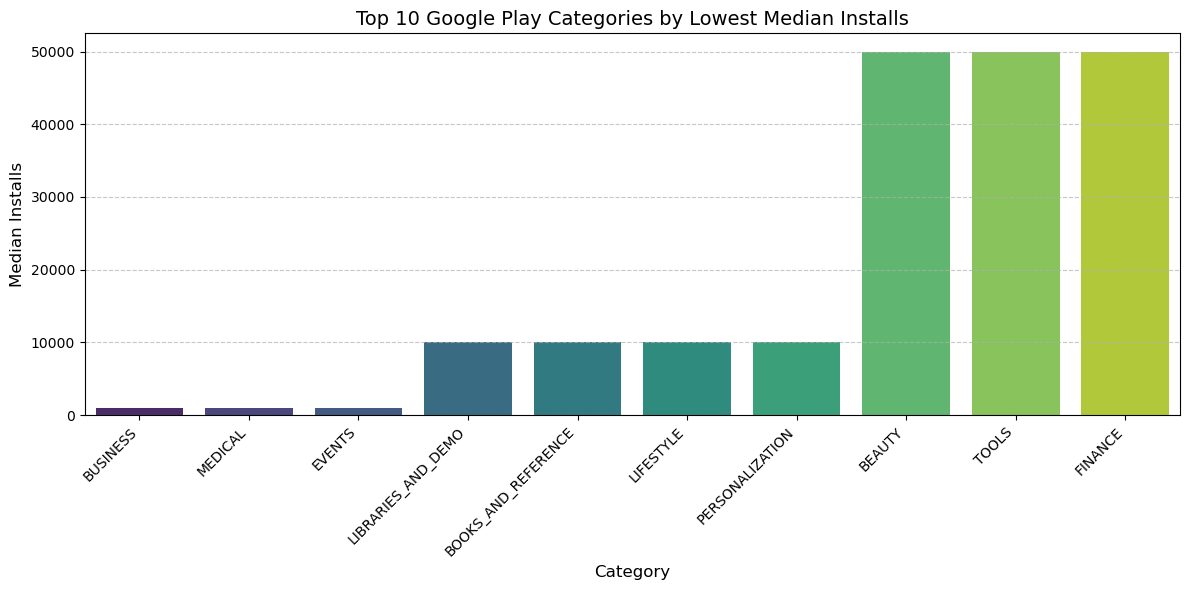

In [34]:
""""Task 1:Визначте 10 категорій, додатки в яких мають найменшу кількість
завантажень. Побудуйте стовпчикову діаграму. """

df['Installs_Numeric'] = df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True)
df['Installs_Numeric'] = pd.to_numeric(df['Installs_Numeric'], errors='coerce')

sorted_installs = sorted(df['Installs_Numeric'].dropna().unique())
install_type = pd.CategoricalDtype(categories=sorted_installs, ordered=True)
df['Installs_Category'] = df['Installs_Numeric'].astype(install_type)

category_installs = df.groupby('Category')['Installs_Numeric'].median().sort_values()

bottom_10_categories = category_installs.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=bottom_10_categories.index, 
    y=bottom_10_categories.values, 
    hue=bottom_10_categories.index,  # Дублюємо вісь X для кольору
    legend=False,                    # Вимикаємо легенду, бо вона зайва
    palette='viridis'
)

plt.title('Top 10 Google Play Categories by Lowest Median Installs', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Median Installs', fontsize=12)
plt.xticks(rotation=45, ha='right') # Поворот підписів, щоб не налазили
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [62]:
"""Task 2: Чи правда, що безкоштовні додатки з категорії «Ігри» мають більший
середній рейтинг, ніж аналогічні платні додатки? """
 
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Rating'] = df['Rating'].clip(lower=0, upper=5)

free_games = df[(df['Category'] == 'GAME') & (df['Type'] == 'Free')]
paid_games = df[(df['Category'] == 'GAME') & (df['Type'] == 'Paid')]

free_mean_rating = free_games['Rating'].mean()
paid_mean_rating = paid_games['Rating'].mean()

print(f"Average Rating for Free Games: {free_mean_rating:.2f}")
print(f"Average Rating for Paid Games: {paid_mean_rating:.2f}")
print("Free games have a higher average rating than paid games." if free_mean_rating > paid_mean_rating else "Paid games have a higher average rating than free games.")


Average Rating for Free Games: 4.28
Average Rating for Paid Games: 4.37
Paid games have a higher average rating than free games.


Content Rating Categories: ['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated']


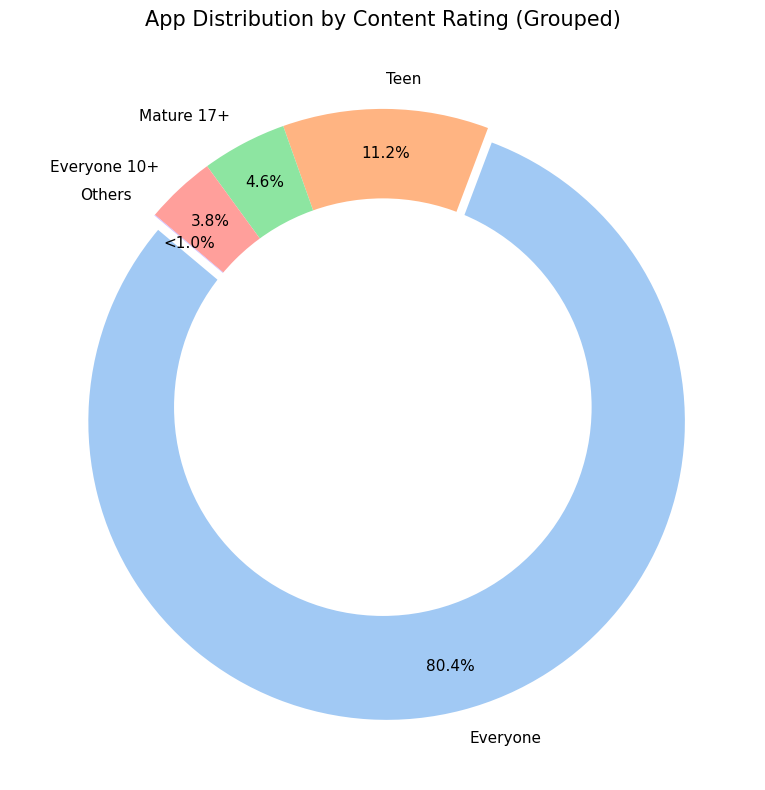

In [49]:
"""Task 3: Побудуйте кругову діаграму розподілу частки додатків за віковими
групами (Content rating). """

counts = df['Content Rating'].value_counts()
rating_cats = df['Content Rating'].unique()
print("Content Rating Categories:", rating_cats)
# 2. Логіка групування "хвоста"
# Визначаємо поріг (наприклад, 2% від загальної кількості)
threshold = 0.02 * counts.sum()

# Розділяємо на "основні" та "дрібні"
main_categories = counts[counts >= threshold]
small_categories = counts[counts < threshold]

# Якщо є дрібні категорії, сумуємо їх в "Others"
if not small_categories.empty:
    main_categories['Others'] = small_categories.sum()

def custom_autopct(pct):
    """
    Якщо відсоток менше 1.0, повертає '<1.0%'.
    В іншому випадку повертає точне значення.
    """
    return '<1.0%' if pct < 1.0 else f'{pct:.1f}%'

# 3. Побудова графіка
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(main_categories)]

# Створюємо explode (відступ) тільки для першого (найбільшого) шматка
explode = [0.05] + [0] * (len(main_categories) - 1)

plt.pie(
    main_categories, 
    labels=main_categories.index, 
    autopct=custom_autopct, 
    startangle=140, 
    colors=colors, 
    explode=explode,
    pctdistance=0.85,
    textprops={'fontsize': 11} # Трохи збільшимо шрифт
)

# Робимо "пончик"
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('App Distribution by Content Rating (Grouped)', fontsize=15, loc='center')
plt.tight_layout()
plt.show()

In [ ]:
"""Task4: Складіть список додатків, які не оновлювались більш ніж 7 років. 
"""
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

print("Old Apps (not updated for more than 7 years from today):")
current_date = pd.to_datetime('today')
df['Years Since Update'] = (current_date - df['Last Updated']).dt.days / 365.25
old_apps = df[df['Years Since Update'] > 7]
old_apps_list = old_apps['App'].unique().tolist()
print(old_apps_list)

print("=" * 50)

print("Old Apps (not updated for more than 7 years from last date in dataset):")
last_date = df['Last Updated'].max()
df['Years Since Update'] = (last_date - df['Last Updated']).dt.days / 365.25
old_apps = df[df['Years Since Update'] > 7]
old_apps_list = old_apps['App'].unique().tolist()
print(old_apps_list)

Old Apps (not updated for more than 7 years from today):
['Photo Editor & Candy Camera & Grid & ScrapBook', 'Coloring book moana', 'U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'Sketch - Draw & Paint', 'Pixel Draw - Number Art Coloring Book', 'Paper flowers instructions', 'Smoke Effect Photo Maker - Smoke Editor', 'Infinite Painter', 'Garden Coloring Book', 'Kids Paint Free - Drawing Fun', 'Text on Photo - Fonteee', 'Name Art Photo Editor - Focus n Filters', 'Tattoo Name On My Photo Editor', 'Mandala Coloring Book', '3D Color Pixel by Number - Sandbox Art Coloring', 'Photo Designer - Write your name with shapes', '350 Diy Room Decor Ideas', 'FlipaClip - Cartoon animation', 'ibis Paint X', 'Logo Maker - Small Business', "Boys Photo Editor - Six Pack & Men's Suit", 'Superheroes Wallpapers | 4K Backgrounds', 'Mcqueen Coloring pages', 'HD Mickey Minnie Wallpapers', 'Harley Quinn wallpapers HD', 'Colorfit - Drawing & Coloring', 'Animated Photo Editor', 'Pencil Sketch Drawing', 'Easy

Empty cells: 1694
Empty cells after filling: 0

Updated size statistics (MB):
count    10829.000000
mean        20.337846
std         21.236170
min          0.008301
25%          5.600000
50%         12.000000
75%         27.000000
max        100.000000
Name: Size_MB, dtype: float64
Category
GAME            44.613116
FAMILY          27.868031
BUSINESS        13.796415
PRODUCTIVITY    11.675067
TOOLS            8.659504
Name: Size_MB, dtype: float64


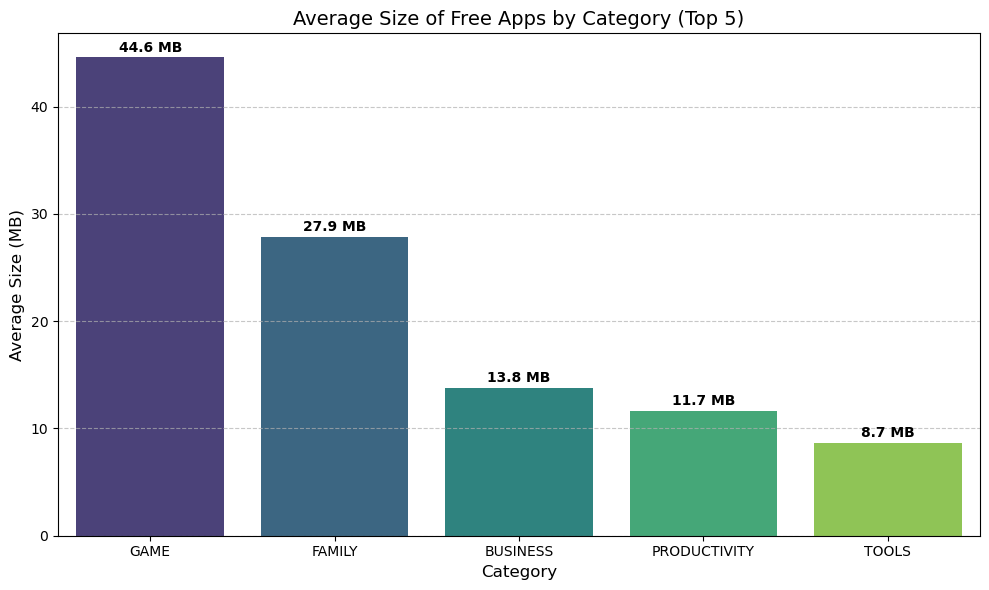

In [63]:
"""Task 5: Порівняйте середню вагу (в мегабайтах) безкоштовних додатків із
довільних 5 категорій. 
"""

def parse_size(size_str):
    if 'Varies with device' in str(size_str):
        return np.nan
    elif 'M' in str(size_str):
        return float(str(size_str).replace('M', ''))
    elif 'k' in str(size_str):
        return float(str(size_str).replace('k', '')) / 1024
    elif str(size_str) == '1,000+':
        return np.nan
    else:
        try:
            return float(size_str)
        except ValueError:
            return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)

print(f"Empty cells: {df['Size_MB'].isnull().sum()}")

df['Size_MB'] = df['Size_MB'].fillna(df.groupby('Category')['Size_MB'].transform('median'))
    
print(f"Empty cells after filling: {df['Size_MB'].isnull().sum()}")
print("\nUpdated size statistics (MB):")
print(df['Size_MB'].describe())

free_apps = df[df['Type'] == 'Free']
top_categories = free_apps['Category'].value_counts().head(5).index.tolist()
subset = free_apps[free_apps['Category'].isin(top_categories)]
avg_size = subset.groupby('Category')['Size_MB'].mean().sort_values(ascending=False)

print(avg_size)

# 4. Візуалізація
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_size.index, y=avg_size.values, hue=avg_size.index, palette='viridis', legend=False)

plt.title('Average Size of Free Apps by Category (Top 5)', fontsize=14)
plt.ylabel('Average Size (MB)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Додамо підписи значень над стовпчиками
for i, v in enumerate(avg_size.values):
    plt.text(i, v + 0.5, f"{v:.1f} MB", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
